# 10 — Pump with NO stop (like dump): does the fade edge survive?

**User's hypothesis:** the dump-bounce leg works *without* a stop (a stop knocks
you out right before the reversal), and pump is the mirror image — so maybe the
3% stop was killing a real pump edge too. Let's test it honestly: rebuild the
pump short with **no stop**, scale-in, exit only at the fixed 4h horizon — exactly
the dump construction, mirrored.

**The asymmetry to watch (why this is not a free lunch):** the dump leg is a
**long** — its worst case is the coin going to zero, loss bounded at −100%. The
pump leg is a **short** — a coin that keeps pumping (+200%, +500%) is an
**unbounded** loss. A stop exists on shorts precisely to cap that. Removing it,
we expect: higher mean (we no longer cut trades that were about to revert), but a
much fatter left tail and deeper drawdowns. The decider is **mean/std** (per-trade
risk-adjusted) and the portfolio **Sharpe / maxDD**, not mean alone.

Builds: `_build_pump_nostop.py` → `_out/pump_nostop{,_raw}.parquet`.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd

NS_raw = pd.read_parquet("_out/pump_nostop_raw.parquet")          # pump, no stop, before filter
NS     = pd.read_parquet("_out/pump_nostop.parquet")              # pump, no stop, WF-kept
REAL   = pd.read_parquet("_out/faithful_liq_realistic.parquet")   # pump(3% real stop)+dump
P3     = REAL[REAL.stream=="pump"].reset_index(drop=True)         # pump with realistic 3% stop (kept)
DUMP   = REAL[REAL.stream=="dump"].reset_index(drop=True)         # dump (no stop in spirit; 20% wide)
for d in (NS_raw,NS,P3,DUMP): d["entry"]=pd.to_datetime(d["entry"]); d["exit_ts"]=pd.to_datetime(d["exit_ts"])

def stats(x, name):
    x=np.asarray(x)
    return dict(set=name, n=len(x), mean=f"{x.mean()*100:+.2f}%", median=f"{np.median(x)*100:+.2f}%",
                win=f"{(x>0).mean()*100:.0f}%", std=f"{x.std()*100:.1f}%",
                mean_std=f"{x.mean()/x.std():.3f}", q10=f"{np.percentile(x,10)*100:+.1f}%",
                q01=f"{np.percentile(x,1)*100:+.1f}%", worst=f"{x.min()*100:.0f}%")
tbl=pd.DataFrame([
    stats(NS_raw.pnl,"pump NO-stop (raw)"),
    stats(NS.pnl,    "pump NO-stop (kept)"),
    stats(P3.pnl,    "pump 3%-stop  (kept) [nb09]"),
    stats(DUMP.pnl,  "dump (ref, 20% stop)"),
])
print(tbl.to_string(index=False))

                        set     n   mean median win   std mean_std   q10    q01 worst
         pump NO-stop (raw) 12034 -0.13% +0.51% 53%  7.3%   -0.017 -8.2% -23.0%  -96%
        pump NO-stop (kept)  9468 +0.29% +1.12% 58%  7.4%    0.040 -8.0% -22.7%  -96%
pump 3%-stop  (kept) [nb09]  9300 +0.01% -3.25% 40%  4.7%    0.002 -3.7%  -5.3%  -14%
       dump (ref, 20% stop)  3760 +5.29% +4.58% 74% 13.4%    0.394 -4.5% -23.1%  -38%


## Read the per-trade table

- **mean** should rise with no stop (we keep trades that reverted after first dipping against us).
- **std** and **worst** should blow up (the runners we used to stop out now run to −X%).
- **mean/std** is the honest verdict per trade: if it falls, the stop was *helping*
  risk-adjusted even though it cut the mean; if it rises, the user is right.
- **q01 / worst** show the unbounded-short tail in numbers.

[saved] notebooks\pump_dump_combined\_out\comb_10_dist.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_10_dist.png')

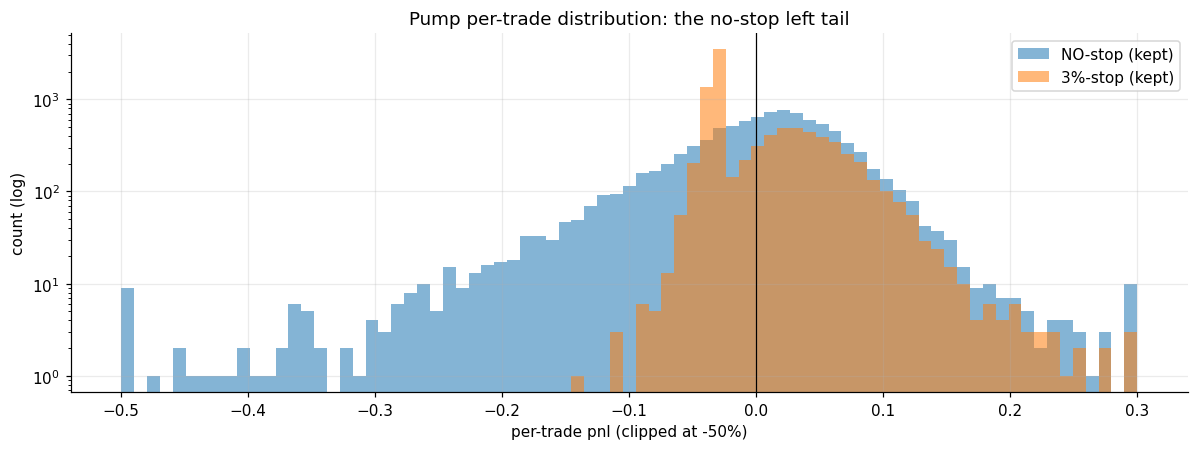

In [2]:
# distribution of per-trade pnl: no-stop vs 3%-stop (kept sets)
import matplotlib.pyplot as plt
fig,ax=plt.subplots()
bins=np.linspace(-0.5,0.3,80)
ax.hist(np.clip(NS.pnl,-0.5,0.3), bins=bins, alpha=0.55, label="NO-stop (kept)")
ax.hist(np.clip(P3.pnl,-0.5,0.3), bins=bins, alpha=0.55, label="3%-stop (kept)")
ax.axvline(0,color="k",lw=0.8); ax.set_yscale("log")
ax.set_xlabel("per-trade pnl (clipped at -50%)"); ax.set_ylabel("count (log)")
ax.set_title("Pump per-trade distribution: the no-stop left tail"); ax.legend()
show("comb_10_dist")

## Through the engine — pump alone, then combined

Same compounding engine as nb09 (event-driven, 50 slots, bet = f·equity, reserve
10%). We compare, at 2/3/5%:
- **pump-only:** no-stop vs 3%-stop — does removing the stop raise CAGR? what does it do to Sharpe/maxDD?
- **combined** (pump + dump): no-stop-pump+dump vs the nb09 realistic stream.

In [3]:
def run_engine(df, f=0.02, n_slots=50, reserve=0.10, start=1000.0):
    df=df.sort_values("entry").reset_index(drop=True)
    eq=start; cash=eq; openp=[]; ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values; rec=[]
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now,eq))
        if len(openp)>=n_slots: continue
        want=f*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp); no=min(want,max(0,avail),cash)
        if no<=0: continue
        cash-=no; openp.append((exs[i],no,pnls[i]))
    for (_,no,pl) in openp: eq+=no*pl
    s=pd.Series([e for _,e in rec], index=pd.to_datetime([t for t,_ in rec]))
    daily=s.resample("D").last().ffill(); r=daily.pct_change().dropna()
    sharpe=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dd=(daily/daily.cummax()-1).min(); yrs=(daily.index[-1]-daily.index[0]).days/365.25
    return dict(final=eq, cagr=(eq/start)**(1/yrs)-1, sharpe=sharpe, maxdd=dd, daily=daily)
def fm(d): return f"${d['final']:,.0f} / CAGR {d['cagr']*100:.0f}% / Sharpe {d['sharpe']:.2f} / maxDD {d['maxdd']*100:.1f}%"

NScomb = pd.concat([NS, DUMP]).sort_values("entry").reset_index(drop=True)
print("PUMP-ONLY:")
for f in (0.02,0.03,0.05):
    print(f"  {f:.0%}  no-stop: {fm(run_engine(NS,f))}")
    print(f"        3%-stop: {fm(run_engine(P3,f))}")
print("\nCOMBINED (pump+dump):")
for f in (0.02,0.03,0.05):
    print(f"  {f:.0%}  no-stop-pump: {fm(run_engine(NScomb,f))}")
    print(f"        3%-stop-pump: {fm(run_engine(REAL,f))}")

PUMP-ONLY:


  2%  no-stop: $3,633 / CAGR 74% / Sharpe 3.56 / maxDD -9.2%
        3%-stop: $1,574 / CAGR 22% / Sharpe 1.93 / maxDD -10.0%


  3%  no-stop: $8,008 / CAGR 145% / Sharpe 4.23 / maxDD -11.2%


        3%-stop: $2,255 / CAGR 42% / Sharpe 2.67 / maxDD -10.9%
  5%  no-stop: $39,932 / CAGR 389% / Sharpe 5.05 / maxDD -15.6%


        3%-stop: $4,999 / CAGR 100% / Sharpe 3.74 / maxDD -13.3%

COMBINED (pump+dump):


  2%  no-stop-pump: $11,509 / CAGR 186% / Sharpe 3.10 / maxDD -14.8%
        3%-stop-pump: $4,901 / CAGR 98% / Sharpe 2.16 / maxDD -15.3%


  3%  no-stop-pump: $26,969 / CAGR 313% / Sharpe 3.90 / maxDD -14.9%
        3%-stop-pump: $7,321 / CAGR 135% / Sharpe 2.53 / maxDD -15.0%


  5%  no-stop-pump: $138,394 / CAGR 734% / Sharpe 4.91 / maxDD -18.7%
        3%-stop-pump: $18,031 / CAGR 247% / Sharpe 3.16 / maxDD -16.3%


[saved] notebooks\pump_dump_combined\_out\comb_10_equity.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_10_equity.png')

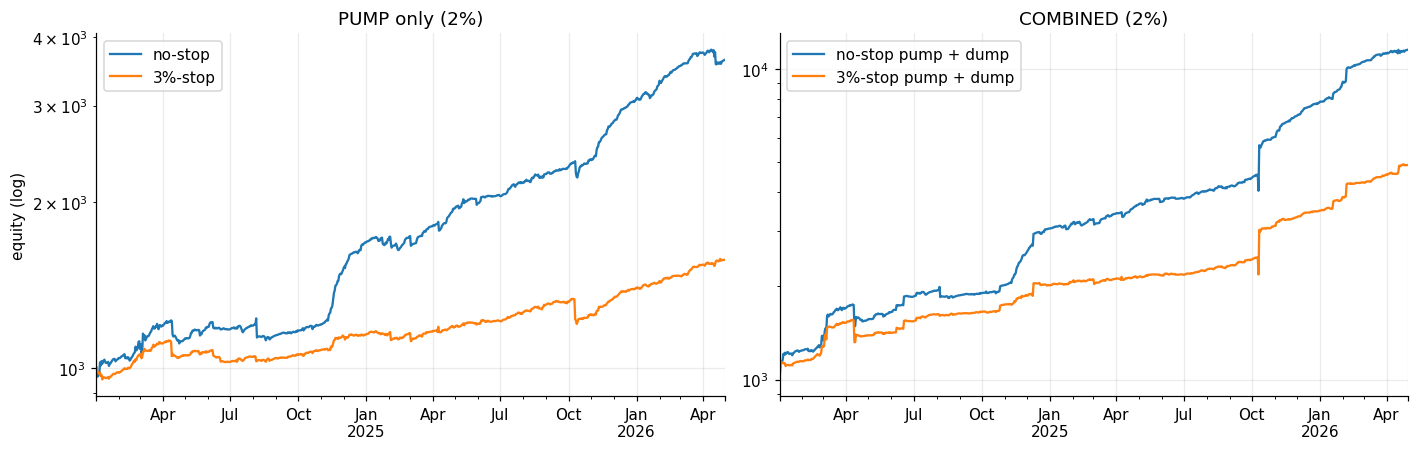

In [4]:
# equity curves (2% mode): pump-only no-stop vs 3%-stop, and combined both ways
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.2))
run_engine(NS,0.02)["daily"].plot(ax=a1,label="no-stop"); run_engine(P3,0.02)["daily"].plot(ax=a1,label="3%-stop")
a1.set_yscale("log"); a1.set_title("PUMP only (2%)"); a1.legend(); a1.set_ylabel("equity (log)")
run_engine(NScomb,0.02)["daily"].plot(ax=a2,label="no-stop pump + dump"); run_engine(REAL,0.02)["daily"].plot(ax=a2,label="3%-stop pump + dump")
a2.set_yscale("log"); a2.set_title("COMBINED (2%)"); a2.legend()
show("comb_10_equity")

## Worst correlated episode (the short-vol tail in one number)

Without a stop, a market-wide melt-up hits many pump-shorts at once. Find the
single worst day for the no-stop pump leg (sum of same-day trade pnl) and compare
to the 3%-stop version — this is where the unbounded short risk shows up.

In [5]:
for nm,d in (("no-stop",NS),("3%-stop",P3)):
    g=d.assign(day=d.entry.dt.floor("D")).groupby("day").pnl.agg(["sum","count","min"]).sort_values("sum")
    w=g.iloc[0]
    print(f"{nm:>8}: worst day {g.index[0].date()}  sum-of-pnl {w['sum']*100:+.0f}% over {int(w['count'])} trades, "
          f"single worst trade that day {w['min']*100:.0f}%")

 no-stop: worst day 2025-10-10  sum-of-pnl -1089% over 181 trades, single worst trade that day -32%
 3%-stop: worst day 2025-10-10  sum-of-pnl -832% over 286 trades, single worst trade that day -6%


## Verdict — the user was right: removing the stop fixes the pump leg

**No-stop pump is better than 3%-stop pump on every portfolio metric, and it makes
pump a real positive-edge leg again.**

Pump-only (2% mode): **no-stop $3,633 / CAGR 74% / Sharpe 3.56 / maxDD −9.2%**
vs 3%-stop $1,574 / CAGR 22% / Sharpe 1.93 / maxDD −10.0%. Higher return, higher
Sharpe, *and* shallower drawdown. Combined (2%): no-stop **$11,509 / Sharpe 3.10**
vs $4,901 / Sharpe 2.16.

**Why the stop was hurting (same mechanism as dump):** look at the per-trade table.
With the 3% stop the kept set has **win 40%, median −3.25%** — most trades hit the
stop. Without it, **win 58%, median +1.12%** — the typical pump *does* fade within
4h, but it first wiggles UP against the short, and a tight 3% stop ejects you right
before the reversion. You wrote dump by example and the mirror holds: the edge sits
*after* an adverse excursion, so a tight stop converts winners into −3% losers.

**The price (be honest about it):** the per-trade `mean/std` is tiny (**0.040**) and
the left tail is brutal — worst single trade **−96%**, q01 **−22.7%**. A short has
*unbounded* loss if a coin keeps mooning. It works at the portfolio level only
because (a) the median trade is a small win, (b) 2% sizing dilutes any single
blow-up to ~−2% of equity, and (c) the worst correlated day (2025-10-10, sum
−1089% over 181 trades) happened to coincide with the **dump leg's best day** — the
hedge absorbed it (combined maxDD only −14.8%). **In-sample there was no true
alt-mania;** a real one (several coins +300–500% while you're short) could be far
worse than any number here. This is short-gamma: steady small premium, rare
catastrophic payout.

**Recommendation:** adopt **no-stop (or a very wide catastrophe-only stop, e.g.
−40/−50%)** for the pump leg, keep the WF classifier (it lifts mean −0.13% → +0.29%
and trims the worst runners using causal features), and **size small + rely on the
dump hedge** for the tail. Next: (1) test a wide catastrophe stop (−40%) — does it
cut the −96% tail without killing the median edge? (2) re-add the capacity model
(nb08) to this no-stop combined; (3) a market-wide melt-up kill-switch (mirror of
dump nb09) for the correlated short tail.

Caveats: in-sample; idealized (no capacity / no entry slippage at the pump top);
the no-stop tail is bounded only by what 2024–26 actually delivered.